In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchviz import make_dot
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

torch.autograd.set_detect_anomaly(True)

In [2]:
# Simulate the process
T = 10.0                         # Total simulation time.
tau = 0.06                    # Correlation decay parameter for the process.
dt = 0.05 * tau                 # Time discretization step for simulation of the process.
sigma = 1.0                     # Standard deviation of the process.
u = 0.0                       # Threshold.
n = 100                         # Number of trials

alpha = 3/2

In [3]:
# Simulate the process and record the crossing times.
upcrossing_times = []
downcrossing_times = []

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_rational_quadratic, T, dt,
        sigma=sigma, tau=tau, alpha=alpha
    )
    upcrossing_times.append(utils.upcrossing_times(x=x, t=t, threshold=u))
    downcrossing_times.append(utils.downcrossing_times(x=x, t=t, threshold=u))

# --------------------------------------------------------------------
# Compute observed upcrossings count per trial
observed_counts = torch.tensor([len(times) for times in upcrossing_times], dtype=torch.float32)
# print("Observed counts:", observed_counts.tolist())

In [4]:
# functions to find the mean and variance of the upcrossing counts.
model = formula.GaussianUpCrossingsDimless(r_func=process.r_rational_quadratic, u=u, tau=tau, alpha=alpha, sigma=sigma)
mean_num_upcrossings = model.upcrossing_mean(T)
variance_num_upcrossings = model.upcrossing_variance(T)

# print the mean and variance of the upcrossing counts.
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings}")

# print the numerical mean and variance of the upcrossing counts.
print(f"Numerical mean number of upcrossings: {observed_counts.mean()}")
print(f"Numerical variance of the number of upcrossings: {observed_counts.var()}")


# the values to fit to
# true_mean = observed_counts.mean()
# true_var = torch.var(observed_counts, correction=0)

true_mean = mean_num_upcrossings
true_var = variance_num_upcrossings

Mean number of upcrossings: 26.525823848649228
Variance of the number of upcrossings: 10.076854890307894
Numerical mean number of upcrossings: 26.729999542236328
Numerical variance of the number of upcrossings: 9.9970703125


Initial parameters:
tau: 0.6
sigma: 1.0
Analytical mean and variance with intial parameters:
Mean number of upcrossings : 2.652582384864923
Variance of the number of upcrossings : 1.124393265494104
epsilon_right = 0.05660377358490565
Epoch    0: Loss = 650.0782, tau = 0.600000, sigma = 1.000000
Epoch   10: Loss = 634.9255, tau = 0.542754, sigma = 1.018151
Epoch   20: Loss = 618.1384, tau = 0.490253, sigma = 0.994562
Epoch   30: Loss = 599.3273, tau = 0.441687, sigma = 0.969936
Epoch   40: Loss = 578.0957, tau = 0.396594, sigma = 0.977802
Epoch   50: Loss = 554.0308, tau = 0.354738, sigma = 0.984229
Epoch   60: Loss = 526.7268, tau = 0.316001, sigma = 0.984084
Epoch   70: Loss = 495.7609, tau = 0.280313, sigma = 0.984925
Epoch   80: Loss = 460.7500, tau = 0.247620, sigma = 0.954042
Epoch   90: Loss = 421.3790, tau = 0.217865, sigma = 0.960085
Optimization complete!
Estimated parameters:
tau: 0.1909833003070373
sigma: 0.9488888532323657


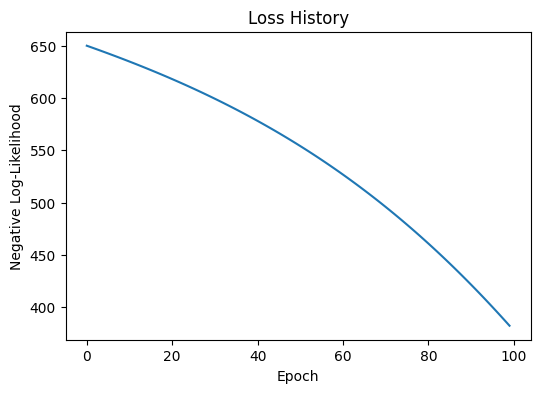

In [5]:
# Set up parameters for optimization.

log_tau = torch.tensor(np.log(0.6), dtype=torch.float64, requires_grad=True)
log_sigma = torch.tensor(np.log(1.0), dtype=torch.float64, requires_grad=True)


# print the intial parameters
print("Initial parameters:")
print(f"tau: {torch.exp(log_tau).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")

print("Analytical mean and variance with intial parameters:")
model_init = formula.GaussianUpCrossingsDimless(r_func=process.r_rational_quadratic, u=u, tau=torch.exp(log_tau).item(), alpha=alpha, sigma=torch.exp(log_sigma).item())
mean_num_upcrossings_init = model_init.upcrossing_mean(T)
variance_num_upcrossings_init = model_init.upcrossing_variance(T)
print(f"Mean number of upcrossings : {mean_num_upcrossings_init}")
print(f"Variance of the number of upcrossings : {variance_num_upcrossings_init}")

print(f"epsilon_right = {1 - (T / torch.exp(log_tau).item()) / (1 + (T / torch.exp(log_tau).item()))}")


# Choose an optimizer
optimizer = torch.optim.Adam([log_tau, log_sigma], lr=1e-2)

# For tracking the loss history
num_epochs = 100
loss_history = []

# --------------------------------------------------------------------
# Optimization loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters ensuring positivity.
    tau_est = torch.exp(log_tau)
    sigma_est = torch.exp(log_sigma)
    
    # Create a model instance with the current estimates.
    model_est = formula.GaussianUpCrossingsDimless(
        r_func=process.r_rational_quadratic, u=u, tau=tau_est, alpha=alpha, sigma=sigma_est
    )
    
    # Compute the predicted mean and variance for the number of upcrossings over time T.
    mean_est = model_est.upcrossing_mean(T)
    var_est = model_est.upcrossing_variance(T)
    # var_est = model_est.upcrossing_variance_CLT(T)

    # print(f"Mean number of upcrossings: {mean_est}")
    # print(f"Variance of the number of upcrossings: {var_est}")
    
    # Define the negative log likelihood assuming a Gaussian likelihood for the counts.
    # For each trial, NLL = 0.5*log(2*pi*var) + 0.5*(observed - mean)^2 / var.
    # nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
    # nll = (observed_counts - mean_est)**2 ## minimize the mean
    # loss = nll.mean()  # Sum over all trials.

    
    # loss = (mean_est - true_mean) ** 2 ## minimize the mean
    # loss = (var_est - true_var) ** 2 ## minimize the variance
    loss = (mean_est - true_mean) ** 2 + (var_est - true_var) ** 2 ## minimize both mean and variance

    # dot = make_dot(loss, params={'log_tau': log_tau, 'log_sigma': log_sigma}, show_attrs=True, show_saved=True)
    # dot.render("computational_graph", format="png")
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, "
              f"tau = {tau_est.item():.6f}, sigma = {sigma_est.item():.6f}")

    
    # Backpropagate the loss.
    loss.backward()

    # print the gradient for each parameter
    # print(f"Gradient tau_e: {log_tau_e.grad}")
    # print(f"Gradient sigma : {log_sigma.grad}")

    optimizer.step()
    
    loss_history.append(loss.item())
    

print("Optimization complete!")
print("Estimated parameters:")
print(f"tau: {torch.exp(log_tau).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")

# Optional: Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss History")
plt.show()

In [6]:
# print the simulation mean and variance with true paramters and learned paramteres
print("Simulation mean and variance with true parameters:")
print(f"Mean number of upcrossings: {torch.mean(observed_counts)}")
print(f"Variance of the number of upcrossings: {torch.var(observed_counts, correction=0)} \n")

# print the analytical mean and variance with true paramters and learned paramteres
print("Analytical mean and variance with true parameters:")
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings} \n")


print("Analytical mean and variance with estimated parameters:")
model_est = formula.GaussianUpCrossingsDimless(r_func=process.r_rational_quadratic, u=u, tau=tau_est, alpha=alpha, sigma=sigma_est)
mean_num_upcrossings_est = model_est.upcrossing_mean(T)
variance_num_upcrossings_est = model_est.upcrossing_variance(T)
print(f"Mean number of upcrossings (estimated): {mean_num_upcrossings_est}")
print(f"Variance of the number of upcrossings (estimated): {variance_num_upcrossings_est}")

Simulation mean and variance with true parameters:
Mean number of upcrossings: 26.729999542236328
Variance of the number of upcrossings: 9.897100448608398 

Analytical mean and variance with true parameters:
Mean number of upcrossings: 26.525823848649228
Variance of the number of upcrossings: 10.076854890307894 

Analytical mean and variance with estimated parameters:
Mean number of upcrossings (estimated): 8.22317763738644
Variance of the number of upcrossings (estimated): 3.2134942688242853
